In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [38]:
df = pd.read_csv('cleaned_data.csv')
df

,patient_name,age,gender,condition,medication,visit_date,cholesterol,systolic,diastolic,visit_year,visit_month
0,david lee,25,other,Heart Disease,METFORMIN,2020-01-15,200.0,140.0,90.0,2020.0,1.0
1,emily davis,35,male,Diabetes,NONE,NaN,200.0,120.0,80.0,2020.0,1.0
2,laura martinez,35,other,Asthma,METFORMIN,NaN,160.0,110.0,70.0,2020.0,1.0
3,michael wilson,35,male,Diabetes,ALBUTEROL,2020-01-15,180.0,110.0,70.0,2020.0,1.0
4,david lee,35,female,Asthma,NONE,NaN,180.0,110.0,70.0,2020.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
995,mary clark,70,other,Asthma,ALBUTEROL,NaN,180.0,110.0,70.0,2020.0,1.0
996,mary clark,35,other,Asthma,LISINOPRIL,2020-01-15,160.0,130.0,85.0,2020.0,1.0
997,laura martinez,35,other,Asthma,ALBUTEROL,NaN,180.0,110.0,70.0,2020.0,1.0
998,jane smith,25,male,Asthma,ALBUTEROL,NaN,200.0,110.0,70.0,2020.0,1.0


In [39]:
features = ['age', 'cholesterol', 'systolic', 'diastolic']

df_out = df.copy()
X = df_out[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

KMeans


In [40]:
K_range = range(2, 5)

inertia = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=50)
    labels = km.fit_predict(X_scaled)

    inertia.append(km.inertia_)  # Elbow method
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

    print(f"K={k} → Inertia: {km.inertia_:.2f}, Silhouette: {sil:.4f}")


K=2 → Inertia: 2490.15, Silhouette: 0.3500
K=3 → Inertia: 1878.95, Silhouette: 0.3724
K=4 → Inertia: 1460.83, Silhouette: 0.3816


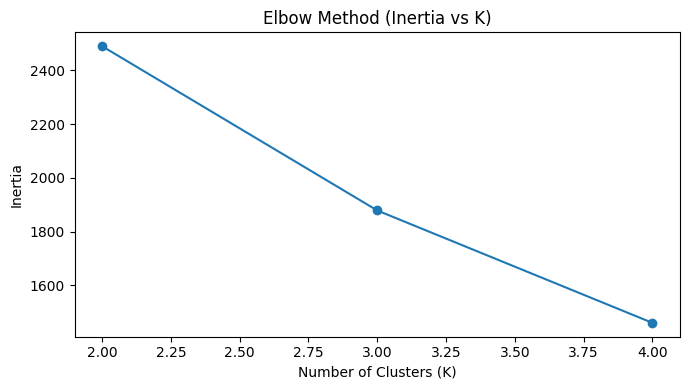

In [52]:
plt.figure(figsize=(7,4))
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method (Inertia vs K)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig('data/elbow_method.png')
plt.show()

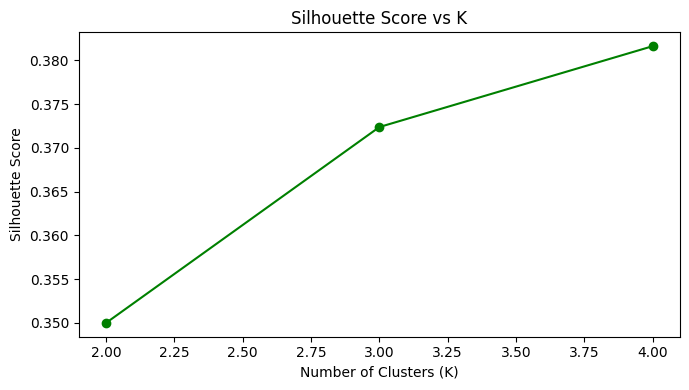

In [53]:
plt.figure(figsize=(7,4))
plt.plot(K_range, sil_scores, marker='o', color='green')
plt.title("Silhouette Score vs K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.savefig('data/silhouette_score.png')
plt.show()

In [43]:
best_k = K_range[np.argmax(sil_scores)]
print(f"\nBest K selected based on silhouette: {best_k}")



Best K selected based on silhouette: 4


In [44]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=50
)

df_out['cluster'] = kmeans.fit_predict(X_scaled)
centers = kmeans.cluster_centers_

In [45]:
final_sil = silhouette_score(X_scaled, df_out['cluster'])
print(f"\nSilhouette score (K={best_k}): {final_sil:.4f}")


Silhouette score (K=4): 0.3816


In [46]:
centroids = scaler.inverse_transform(centers)
centroid_df = pd.DataFrame(centroids, columns=features)

print("\n Cluster Centroids (Original Scale):")
print(centroid_df)


 Cluster Centroids (Original Scale):
         age  cholesterol    systolic  diastolic
0  32.515528   173.788820  130.372671  85.186335
1  35.172414   210.775862  131.120690  85.560345
2  65.191489   182.978723  129.914894  84.957447
3  43.720379   185.971564  110.000000  70.000000


In [47]:
print("\n Cluster Mean Summary:")
cluster_mean = df_out.groupby('cluster')[features].mean()
print(cluster_mean)


 Cluster Mean Summary:
               age  cholesterol    systolic  diastolic
cluster                                               
0        32.515528   173.788820  130.372671  85.186335
1        35.172414   210.775862  131.120690  85.560345
2        65.191489   182.978723  129.914894  84.957447
3        43.720379   185.971564  110.000000  70.000000


In [48]:

print("\n CLUSTER INTERPRETATION (What each cluster represents):\n")

for i in range(best_k):
    cluster_data = df_out[df_out['cluster'] == i]

    print(f"\n Cluster {i}")

    print(f"Size: {len(cluster_data)} patients")

    print("\nFeature Averages:")
    print(cluster_data[features].mean())

    print("\nMost common condition:")
    print(cluster_data['condition'].value_counts().head(3))

    print("\nMost common medication:")
    print(cluster_data['medication'].value_counts().head(3))

    print("-" * 50)


 CLUSTER INTERPRETATION (What each cluster represents):


 Cluster 0
Size: 322 patients

Feature Averages:
age             32.515528
cholesterol    173.788820
systolic       130.372671
diastolic       85.186335
dtype: float64

Most common condition:
condition
Asthma          139
Diabetes         66
Hypertension     61
Name: count, dtype: int64

Most common medication:
medication
METFORMIN       78
ATORVASTATIN    65
LISINOPRIL      64
Name: count, dtype: int64
--------------------------------------------------

 Cluster 1
Size: 232 patients

Feature Averages:
age             35.172414
cholesterol    210.775862
systolic       131.120690
diastolic       85.560345
dtype: float64

Most common condition:
condition
Asthma           100
Heart Disease     46
Diabetes          45
Name: count, dtype: int64

Most common medication:
medication
ATORVASTATIN    51
METFORMIN       50
ALBUTEROL       46
Name: count, dtype: int64
--------------------------------------------------

 Cluster 2
Size: 235

DBSCAN

In [49]:
db = DBSCAN(eps=0.5, min_samples=5)
db_clusters = db.fit_predict(X_pca)

print("DBSCAN:")
print("  Noise points:", sum(db_clusters == -1))
print("  Clusters found:", len(set(db_clusters)) - (1 if -1 in db_clusters else 0))

DBSCAN:
  Noise points: 0
  Clusters found: 4


DBSCAN vs KMEANS

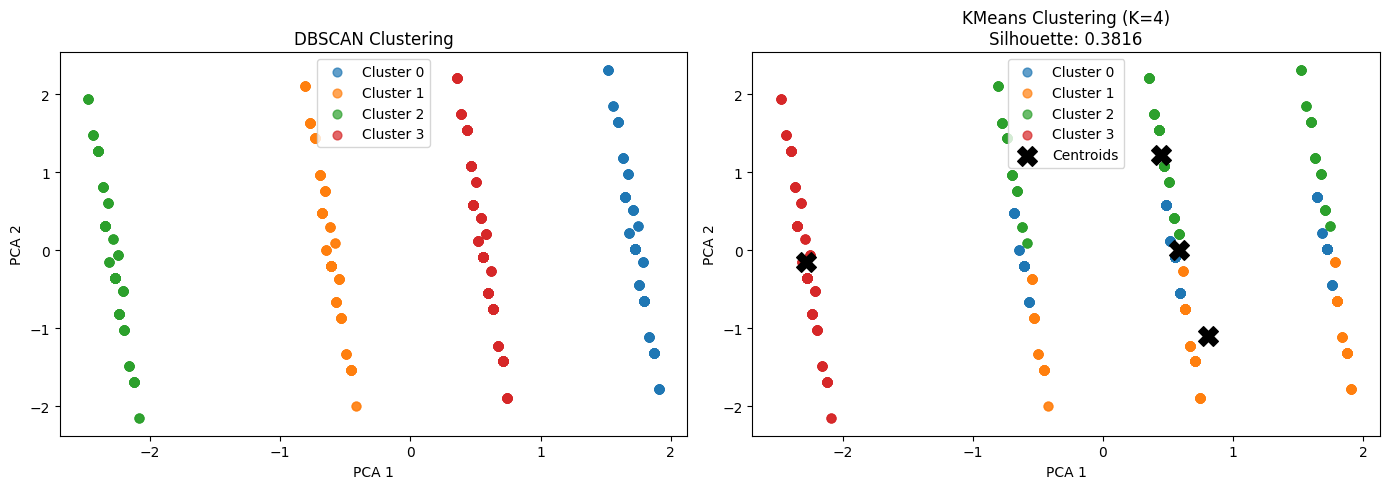

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DBSCAN
unique_clusters = sorted(set(db_clusters))
tab_colors = plt.cm.tab10.colors

for i, cid in enumerate(unique_clusters):
    mask  = db_clusters == cid
    label = 'Noise' if cid == -1 else f'Cluster {cid}'
    color = 'lightgray' if cid == -1 else tab_colors[i % len(tab_colors)]
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=color,
        label=label, s=40, alpha=0.7
    )

axes[0].set_title('DBSCAN Clustering')
axes[0].set_xlabel('PCA 1')
axes[0].set_ylabel('PCA 2')
axes[0].legend()

# KMeans 
colors = cm.tab10(range(best_k))

for i in range(best_k):
    mask = df_out['cluster'] == i
    axes[1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=[colors[i]], label=f'Cluster {i}', s=40, alpha=0.7
    )

axes[1].scatter(
    centers_pca[:, 0], centers_pca[:, 1],
    color='black', marker='X', s=200, zorder=5, label='Centroids'
)

axes[1].set_title(f'KMeans Clustering (K={best_k})\nSilhouette: {final_sil:.4f}')
axes[1].set_xlabel('PCA 1')
axes[1].set_ylabel('PCA 2')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/clustering_comparision.png')
plt.show()